In [1]:
import pandas as pd

df=pd.read_csv(r"C:\Users\UDIT KUMAR\Downloads\spam.csv", encoding='latin-1'
)

In [2]:

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.shape


(5572, 5)

Data cleaning


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
#drop last 3 columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [6]:
df.rename(columns={'v1':'Target','v2':'Message'},inplace= True)
df.rename(columns={'v1':'Target','v2':'Message'},inplace=True)

In [7]:
from sklearn.preprocessing import LabelEncoder
en=LabelEncoder()

In [8]:
df['Target']=en.fit_transform(df['Target'])

In [9]:
df.isnull().sum()


Target     0
Message    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(403)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(5169, 2)

2.EDA

In [13]:
#figure out 
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x2c3256ac1a0>,
 [Text(-1.014499732282844, 0.4251944181172162, 'Ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'Spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

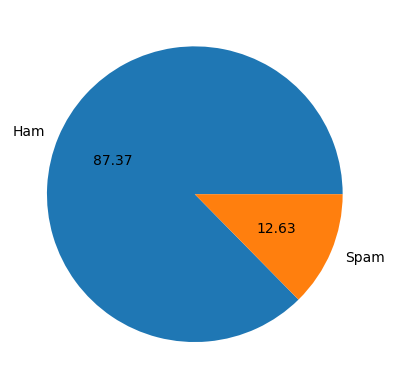

In [14]:
import matplotlib.pyplot as plt
plt.pie(df['Target'].value_counts(),labels=['Ham','Spam'],autopct="%0.2f")

In [15]:
#Data is impalace
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\UDIT
[nltk_data]     KUMAR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [16]:
df['Message_char_num']=df['Message'].apply(len)# number of alphabate use in message
#number of words use in message
df['Message_num_of_words']=df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))
#number of sentense use in message
df['Message_num_of_sentense']=df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [17]:
# for ham message
df[df['Target'] == 0][['Message_char_num','Message_num_of_words','Message_num_of_sentense']].describe()

,Message_char_num,Message_num_of_words,Message_num_of_sentense
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [18]:
# for spam message
df[df['Target'] == 1][['Message_char_num','Message_num_of_words','Message_num_of_sentense']].describe()

,Message_char_num,Message_num_of_words,Message_num_of_sentense
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [19]:
df['Target']==0

0        True
1        True
2       False
3        True
4        True
        ...  
5567    False
5568     True
5569     True
5570     True
5571     True
Name: Target, Length: 5169, dtype: bool

In [20]:
import seaborn as sns
import matplotlib.pyplot as py


<Axes: xlabel='Message_char_num', ylabel='Count'>

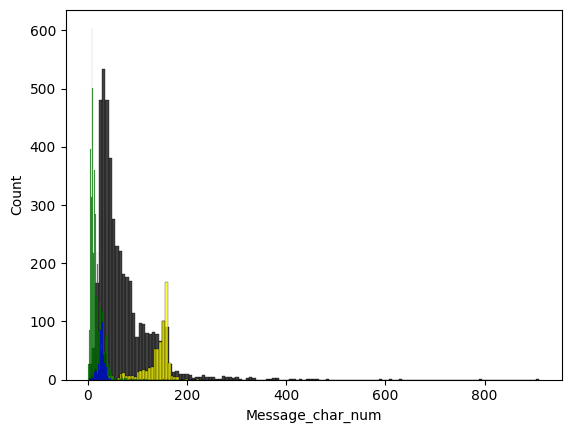

In [21]:

sns.histplot(df[df['Target']==0]['Message_char_num'],color='Black')
sns.histplot(df[df['Target']==1]['Message_char_num'],color='Yellow')
sns.histplot(df[df['Target']==0]['Message_num_of_words'],color='green')
sns.histplot(df[df['Target']==1]['Message_num_of_words'],color='blue')




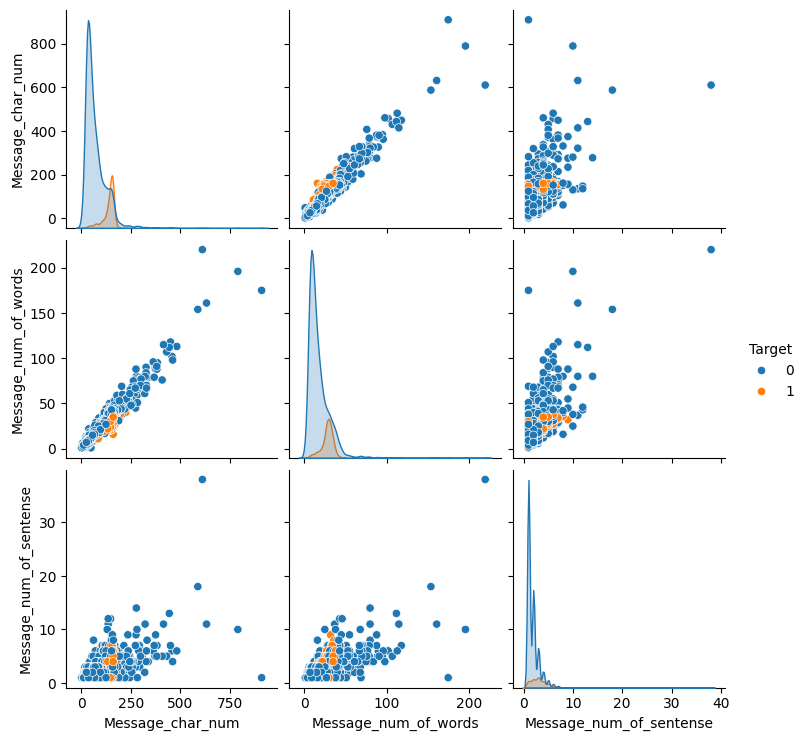

In [22]:
sns.pairplot(df,hue='Target')

<Axes: >

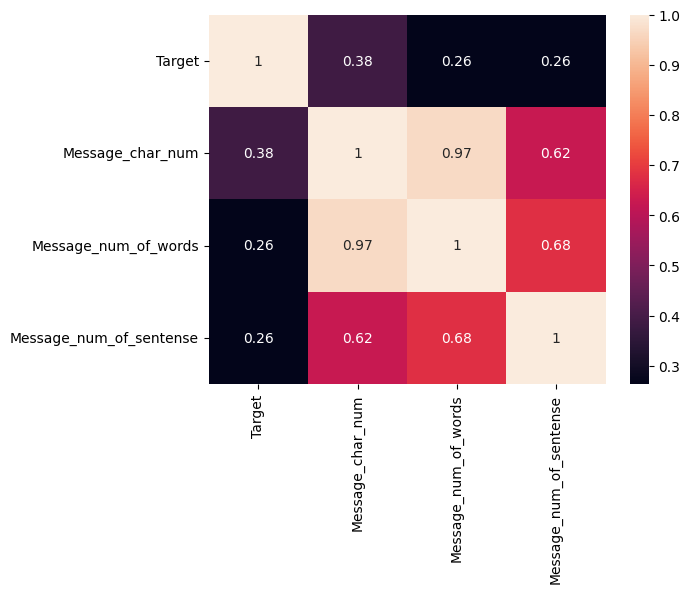

In [23]:
sns.heatmap(df[['Target','Message_char_num', 'Message_num_of_words', 'Message_num_of_sentense']].corr(),annot=True)
#Target vs other factor are only require here and message_char_num vs Target is having most correlation

In [24]:
#so here i am making a function that will do all these work
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Tokenization (words)
    tokens = nltk.word_tokenize(text)
    
    # 3. Remove special characters (keep only alphanumeric)
    tokens = [word for word in tokens if word.isalnum()]
    
    # 4. Remove stopwords
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    
    # 5. Stemming
    tokens = [ps.stem(word) for word in tokens]
    
    # 6. Join back to string
    return " ".join(tokens)
    
            

In [26]:
df['Transform_text']=df['Message'].apply(Transformer_message)

In [27]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [28]:
spam_wc = wc.generate(
    df[df['Target'] == 1]['Transform_text'].str.cat(sep=" ")
)

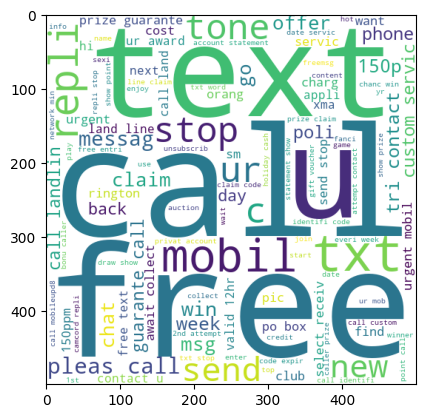

In [29]:
plt.imshow(spam_wc)

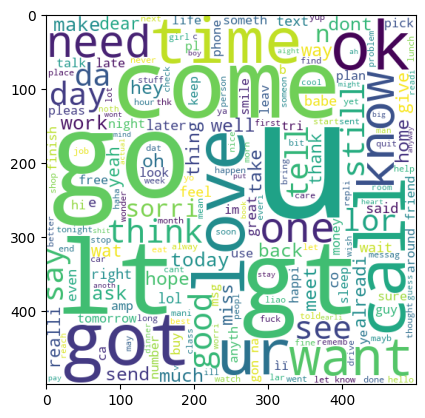

In [30]:
ham_wc = wc.generate(
    df[df['Target'] == 0]['Transform_text'].str.cat(sep=" ")
)
plt.imshow(ham_wc)

In [31]:
spam_corpus=[]
for msg in df[df['Target'] == 1]['Transform_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        
    

In [32]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [33]:
ham_corpus=[]
for msg in df[df['Target'] == 0]['Transform_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
from collections import Counter
Counter(ham_corpus).most_common(30)
        

[('u', 883),
 ('go', 404),
 ('get', 349),
 ('gt', 288),
 ('lt', 287),
 ('2', 284),
 ('come', 275),
 ('got', 236),
 ('know', 236),
 ('like', 234),
 ('call', 233),
 ('time', 219),
 ('ok', 217),
 ('love', 216),
 ('good', 213),
 ('want', 208),
 ('ur', 197),
 ('day', 190),
 ('need', 170),
 ('one', 165),
 ('lor', 159),
 ('4', 156),
 ('home', 152),
 ('think', 149),
 ('see', 147),
 ('take', 143),
 ('still', 143),
 ('da', 142),
 ('tell', 133),
 ('make', 129)]

## 4.model buliding


In [49]:
#know first convert that main input Transformer_message to vector using tfid
from sklearn.feature_extraction.text import TfidfVectorizer
tf=TfidfVectorizer(max_features=3000)
x=tf.fit_transform(df['Transform_text']).toarray()

In [50]:
y=df['Target'].values

In [51]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
#naive_base model use
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import f1_score,confusion_matrix,accuracy_score,precision_score
gb=GaussianNB()
mu=MultinomialNB()
be=BernoulliNB()

In [38]:

gb.fit(x_train,y_train)
y_pred1=gb.predict(x_test)
print(confusion_matrix(y_test,y_pred1))
print(f1_score(y_test,y_pred1))


[[772 117]
 [ 24 121]]
0.6318537859007833


In [53]:

mu.fit(x_train,y_train)
y_pred2=mu.predict(x_test)
print(confusion_matrix(y_test,y_pred2))
print(f1_score(y_test,y_pred2))


[[888   1]
 [ 27 118]]
0.8939393939393939


In [40]:

be.fit(x_train,y_train)
y_pred3=be.predict(x_test)
print(confusion_matrix(y_test,y_pred3))
print(f1_score(y_test,y_pred3))


[[885   4]
 [ 31 114]]
0.8669201520912547


In [41]:
#Now trying diffrent models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


In [54]:
#making object of all kind of models
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [43]:
# dict creation for all models
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [44]:
#func for training
def training_models(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_predict=clf.predict(x_test)
    accuracy=accuracy_score(y_test,y_predict)
    precision=precision_score(y_test,y_predict)
    return accuracy,precision

In [55]:
#calling function
acc=[]
pre=[]
for name,clf in clfs.items():
    A,P=training_models(clf, x_train,y_train,x_test,y_test)
    acc.append(A)
    pre.append(P)
    

In [56]:
Various_Models=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':acc,'Precision':pre}).sort_values('Precision',ascending=False)

In [57]:
Various_Models

,Algorithm,Accuracy,Precision
1,KN,0.904255,1.000000
8,ETC,0.979691,1.000000
2,NB,0.972921,0.991597
5,RF,0.971954,0.991525
9,GBDT,0.949710,0.951456
0,SVC,0.975822,0.947761
10,xgb,0.968085,0.937500
7,BgC,0.960348,0.876812
4,LR,0.946809,0.862903
3,DT,0.931335,0.813559


In [60]:
import pickle
pickle.dump(transform_text,open('Transform.pkl','wb'))
pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(mu,open('model.pkl','wb'))